## ИИММ: практическая работа 8

Суть работы:  
Показать понимание архитектур, алгоритмов обучения и функций потерь в GAN, VAE, а также получить практический опыт работы с этими моделями на небольших наборах данных (например, MNIST).

План работы:  
1. Реализация и обучение Variational Autoencoder (VAE)
    - Vanilla VAE;
    - Conditional VAE;
    - Улучшение модели.
2. Реализация и обучение Generative Adversarial Network GAN
    - Vanilla GAN;
    - Conditional GAN.
3. Анализ латентного пространства и интерполяция (для VAE и GAN).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader
import torchvision.datasets as dset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm import tqdm

### Этап 1а. Реализация и обучение Vanilla VAE

#### Реализация

In [2]:
class Encoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(Encoder, self).__init__()
        self.fc_h = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = F.relu(self.fc_h(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

In [3]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=20, hidden_dim=400, output_dim=784):
        super(Decoder, self).__init__()
        self.fc_h = nn.Linear(latent_dim, hidden_dim)
        self.fc_recon = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        h = F.relu(self.fc_h(z))
        x_recon = F.sigmoid(self.fc_recon(h))
        return x_recon

In [4]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        epsilon = torch.randn_like(std)
        z = mu + std * epsilon
        return z

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

In [2]:
# Определите функцию потерь: Потери при реконструкции (BCE) + потери при расхождении KL
def loss_function(recon_x, x, mu, logvar):
    # Вычислите бинарную потерю перекрестной энтропии между реконструированным выходом и оригинальным входом
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    # Вычислите KL-расхождение между q(z|x) и p(z) = N(0, I)
    KL = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KL

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

mnist_train = dset.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)

In [7]:
hidden_dim = 400
latent_dim = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE(input_dim=784, hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
num_epochs = 30
model = model.to(device)
model.train()
for epoch in range(num_epochs):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):

        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

        if batch_idx % 100 == 0:
            print(f'Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item() / len(data):.6f}')
            
    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')

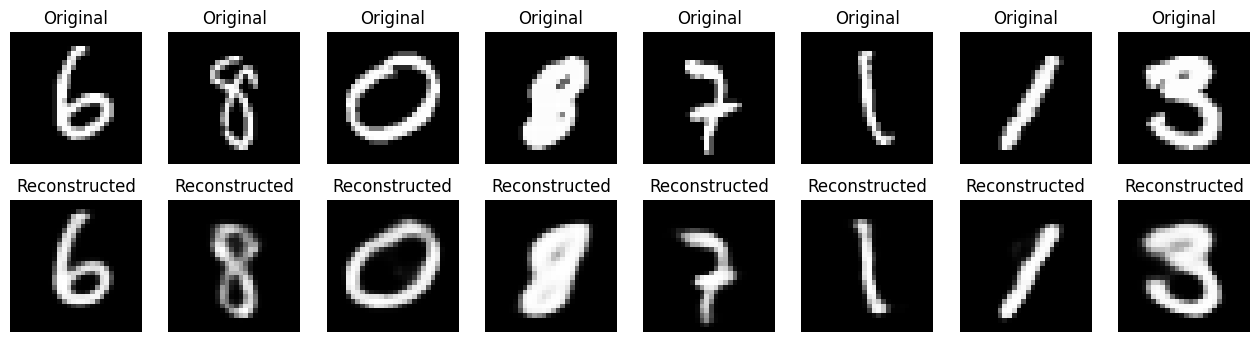

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

mnist_test = dset.MNIST(root='./data', train=False, transform=transform, download=True)
test_loader = torch.utils.data.DataLoader(mnist_test, batch_size=16, shuffle=True)

model.eval() 

data_iter = iter(test_loader)
images, _ = next(data_iter)
images = images.to(device)

with torch.no_grad():
    recon_images, mu, logvar = model(images)

def plot_images(original, reconstructed, n=8):
    plt.figure(figsize=(16, 4))
    for i in range(n):
        plt.subplot(2, n, i+1)
        plt.imshow(original[i].cpu().view(28, 28), cmap='gray')
        plt.title("Original")
        plt.axis("off")
        plt.subplot(2, n, i+n+1)
        plt.imshow(reconstructed[i].cpu().view(28, 28), cmap='gray')
        plt.title("Reconstructed")
        plt.axis("off")
    plt.show()

plot_images(images, recon_images, n=8)

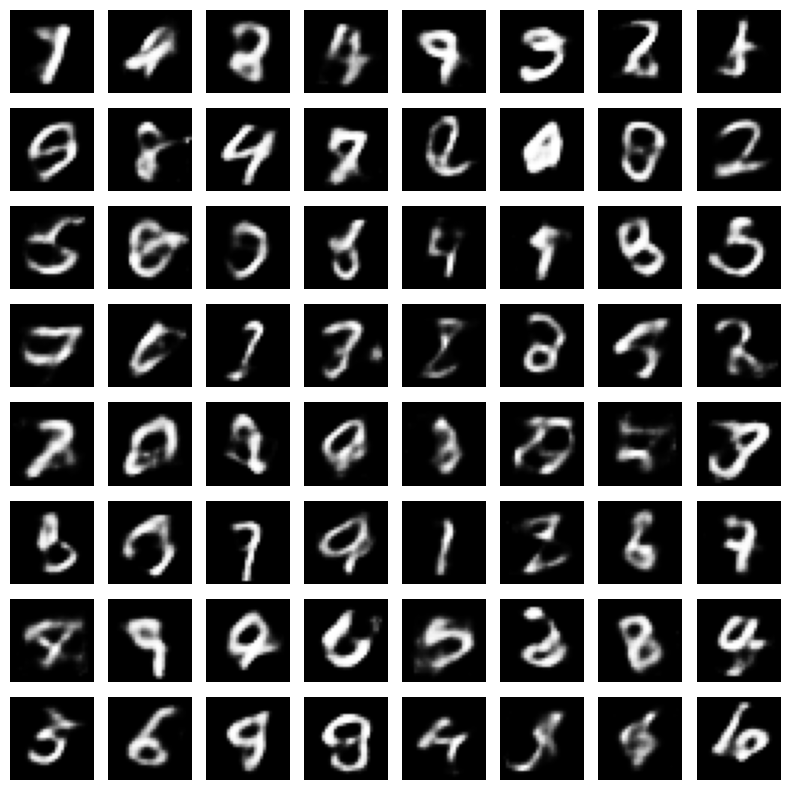

In [10]:
with torch.no_grad():
    z = torch.randn(64, latent_dim, device=device)
    generated_images = model.decoder(z)

def plot_generated(images):
    fig, axes = plt.subplots(8, 8, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        img = images[i].view(28,28).cpu().numpy()
        ax.imshow(img, cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_generated(generated_images)

### Этап 1б. Реализация и обучение Conditional VAE

In [11]:
class ConditionalEncoder(nn.Module):
    def __init__(self, input_dim=784, condition_dim=10, hidden_dim=400, latent_dim=20):
        super(ConditionalEncoder, self).__init__()
        self.fc_h = nn.Linear(input_dim + condition_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x, c):
        input = torch.cat([x, c], dim=1)
        h = F.relu(self.fc_h(input))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

In [12]:
class ConditionalDecoder(nn.Module):
    def __init__(self, latent_dim=20, condition_dim=10, hidden_dim=400, output_dim=784):
        super(ConditionalDecoder, self).__init__()
        self.fc_h = nn.Linear(latent_dim + condition_dim, hidden_dim)
        self.fc_recon = nn.Linear(hidden_dim, output_dim)

    def forward(self, z, c):
        input = torch.cat([z, c], dim=1)
        h = F.relu(self.fc_h(input))
        x_recon = F.sigmoid(self.fc_recon(h))
        return x_recon

In [13]:
class ConditionalVAE(nn.Module):
    def __init__(self, input_dim=784, condition_dim=10, hidden_dim=400, latent_dim=50):
        super(ConditionalVAE, self).__init__()
        self.encoder = ConditionalEncoder(input_dim, condition_dim, hidden_dim, latent_dim)
        self.decoder = ConditionalDecoder(latent_dim, condition_dim, hidden_dim, input_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + std * epsilon
        return z

    def forward(self, x, c):
        mu, logvar = self.encoder(x, c)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z, c)
        return x_recon, mu, logvar

In [14]:
batch_size = 128
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

train_dataset = dset.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = dset.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [15]:
hidden_dim = 400
latent_dim = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConditionalVAE(input_dim=784, condition_dim=10, hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
num_epochs = 40
model.train()

for epoch in tqdm(range(1, num_epochs + 1)):
    train_loss = 0
    for batch_idx, (data, labels) in enumerate(train_loader):

        data = data.to(device)
        labels = labels.to(device)
        conditions = F.one_hot(labels, 10)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data, conditions)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

        if batch_idx % 100 == 0:
            print(f'Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item() / len(data):.6f}')
            
    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')

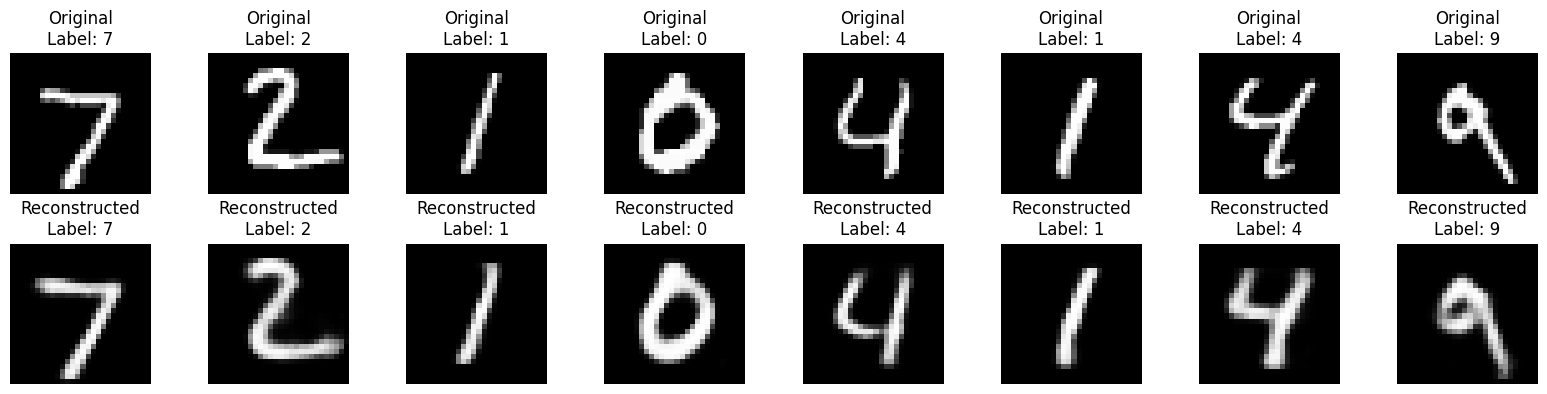

In [17]:
data_iter = iter(test_loader)
images, labels = next(data_iter)
images = images.to(device)
labels = labels.to(device)

conditions = F.one_hot(labels, 10)

with torch.no_grad():
    recon_images, mu, logvar = model(images, conditions)

def plot_images(original, reconstructed, conditions, n=8):
    labels = conditions.argmax(dim=1)
    plt.figure(figsize=(16, 4))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(original[i].cpu().view(28, 28), cmap='gray')
        plt.title(f"Original\nLabel: {labels[i].item()}")
        plt.axis("off")
        plt.subplot(2, n, i + n + 1)
        plt.imshow(reconstructed[i].cpu().view(28, 28), cmap='gray')
        plt.title(f"Reconstructed\nLabel: {labels[i].item()}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_images(images, recon_images, conditions, n=8)

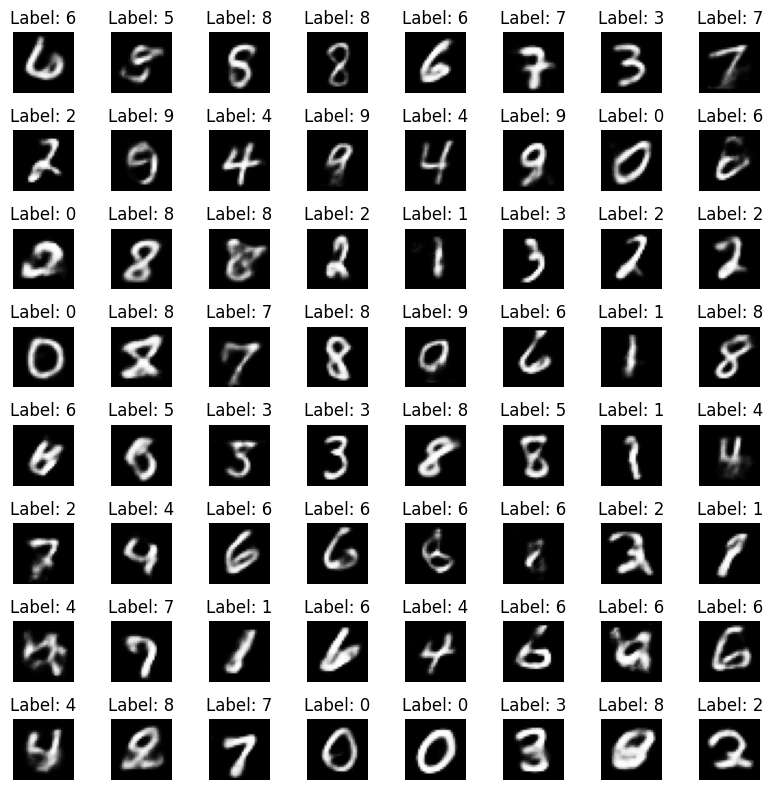

In [20]:
with torch.no_grad():
    z = torch.randn(64, latent_dim, device=device)

    random_labels = torch.randint(0, 10, (64,)).to(device)
    conditions = F.one_hot(random_labels, 10)

    generated_images = model.decoder(z, conditions)

def plot_generated(images):
    fig, axes = plt.subplots(8, 8, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        img = images[i].view(28,28).cpu().numpy()
        ax.imshow(img, cmap="gray")
        ax.set_title(f"Label: {random_labels[i].item()}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_generated(generated_images)

### Этап 1в. Улучшение VAE

In [3]:
class BetterEncoder(nn.Module):
    def __init__(self, input_dim=784, condition_dim=10, hidden_dim=400, latent_dim=20):
        super(BetterEncoder, self).__init__()
        self.fc_h1 = nn.Linear(input_dim + condition_dim, hidden_dim)
        self.fc_h2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)

    def forward(self, x, c):
        input = torch.cat([x, c], dim=1)
        h = F.relu(self.fc_h2(
            F.relu(self.fc_h1(input))
            ))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

In [4]:
class BetterDecoder(nn.Module):
    def __init__(self, latent_dim=20, condition_dim=10, hidden_dim=400, output_dim=784):
        super(BetterDecoder, self).__init__()
        self.fc_h = nn.Linear(latent_dim + condition_dim, hidden_dim // 2)
        self.fc_recon1 = nn.Linear(hidden_dim // 2, hidden_dim)
        self.fc_recon2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, z, c):
        input = torch.cat([z, c], dim=1)
        h = F.relu(self.fc_h(input))
        x_recon = F.sigmoid(self.fc_recon2(F.relu(self.fc_recon1(h))))
        return x_recon

In [5]:
class BetterVAE(nn.Module):
    def __init__(self, input_dim=784, condition_dim=10, hidden_dim=400, latent_dim=50):
        super(BetterVAE, self).__init__()
        self.encoder = BetterEncoder(input_dim, condition_dim, hidden_dim, latent_dim)
        self.decoder = BetterDecoder(latent_dim, condition_dim, hidden_dim, input_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + std * epsilon
        return z

    def forward(self, x, c):
        mu, logvar = self.encoder(x, c)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z, c)
        return x_recon, mu, logvar

In [6]:
batch_size = 64
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

train_dataset = dset.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = dset.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [7]:
hidden_dim = 400
latent_dim = 100

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BetterVAE(input_dim=784, condition_dim=10, hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.5e-3)

In [ ]:
num_epochs = 256
model.train()

for epoch in tqdm(range(1, num_epochs + 1)):
    train_loss = 0
    for batch_idx, (data, labels) in enumerate(train_loader):

        data = data.to(device)
        labels = labels.to(device)
        conditions = F.one_hot(labels, 10)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data, conditions)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

        if batch_idx % 100 == 0:
            print(f'Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item() / len(data):.6f}')
            
    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')

In [9]:
torch.save(model.state_dict(), 'cvae_weights.pth')

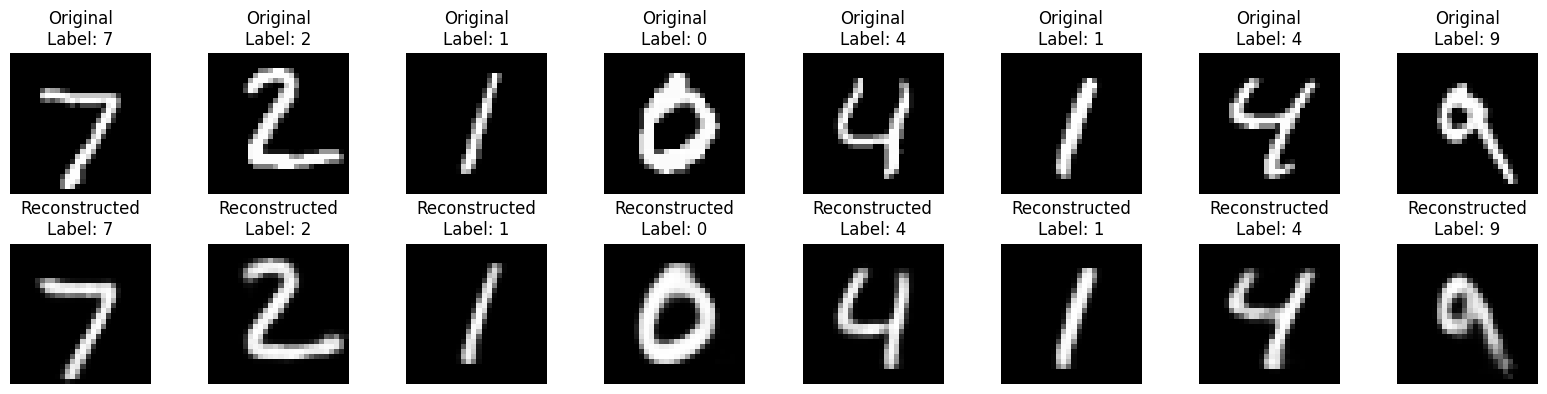

In [10]:
data_iter = iter(test_loader)
images, labels = next(data_iter)
images = images.to(device)
labels = labels.to(device)

conditions = F.one_hot(labels, 10)

with torch.no_grad():
    recon_images, mu, logvar = model(images, conditions)

def plot_images(original, reconstructed, conditions, n=8):
    labels = conditions.argmax(dim=1)
    plt.figure(figsize=(16, 4))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(original[i].cpu().view(28, 28), cmap='gray')
        plt.title(f"Original\nLabel: {labels[i].item()}")
        plt.axis("off")
        plt.subplot(2, n, i + n + 1)
        plt.imshow(reconstructed[i].cpu().view(28, 28), cmap='gray')
        plt.title(f"Reconstructed\nLabel: {labels[i].item()}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_images(images, recon_images, conditions, n=8)

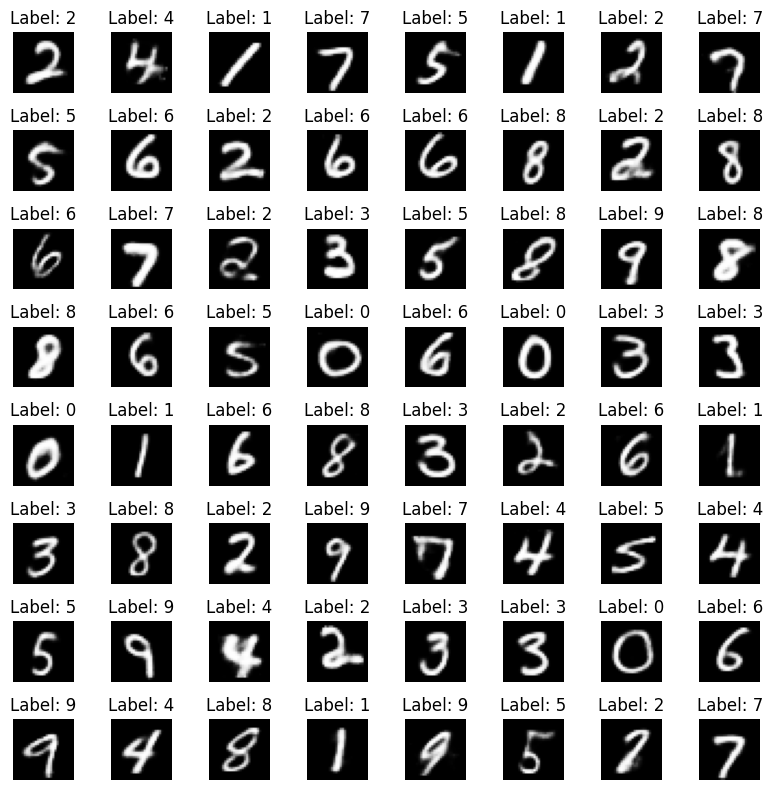

In [18]:
with torch.no_grad():
    z = torch.randn(64, latent_dim, device=device)

    random_labels = torch.randint(0, 10, (64,)).to(device)
    conditions = F.one_hot(random_labels, 10)

    generated_images = model.decoder(z, conditions)

def plot_generated(images):
    fig, axes = plt.subplots(8, 8, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        img = images[i].view(28,28).cpu().numpy()
        ax.imshow(img, cmap="gray")
        ax.set_title(f"Label: {random_labels[i].item()}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_generated(generated_images)

### Этап 2а. Реализация и обучение Vanilla GAN

In [2]:
class Generator(nn.Module):
    def __init__(self, noise_dim = 100, output_shape = (1, 28, 28)):
        super(Generator, self).__init__()

        self.output_shape = output_shape
        output_dim = int(torch.prod(torch.tensor(output_shape)))

        self.fc = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512), 
            nn.ReLU(),
            nn.Linear(512, 768),
            nn.BatchNorm1d(768),
            nn.ReLU(),
            nn.Linear(768, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Linear(1024, output_dim),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.fc(z)
        img = img.view(z.size(0), *self.output_shape)
        return img

In [3]:
class Discriminator(nn.Module):
    def __init__(self, input_shape=(1, 28, 28)):
        super(Discriminator, self).__init__()

        input_dim = int(torch.prod(torch.tensor(input_shape)))

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 1024),
            nn.LeakyReLU(0.2, True),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        result = self.fc(img)
        return result


In [4]:
batch_size = 64
noise_dim = 100

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = dset.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = dset.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

criterion = nn.BCELoss()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = Generator().to(device)
discriminator = Discriminator().to(device)

optimizer_g = optim.Adam(generator.parameters(), lr=1e-4, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.5, 0.999))

In [ ]:
epochs = 100
num_batches = len(train_loader)

generator.train()

for epoch in tqdm(range(epochs)):
    d_loss_total = 0
    g_loss_total = 0
    for i, (real_images, _) in enumerate(train_loader):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        real_labels = torch.ones((batch_size, 1), device=device)
        fake_labels = torch.zeros((batch_size, 1), device=device)

        optimizer_d.zero_grad()
        outputs = discriminator(real_images)
        d_loss_real = criterion(outputs, real_labels)
        d_loss_real.backward()

        noise = torch.randn((batch_size, 100), device=device)
        fake_images = generator(noise)
        outputs = discriminator(fake_images.detach())
        d_loss_fake = criterion(outputs, fake_labels)
        d_loss_fake.backward()

        optimizer_d.step()

        d_loss = d_loss_real + d_loss_fake
        d_loss_total += d_loss.item()

        optimizer_g.zero_grad()
        outputs = discriminator(fake_images)
        g_loss = criterion(outputs, real_labels)
        g_loss.backward()

        optimizer_g.step()

        g_loss_total += g_loss.item()

    print(f'Epoch [{epoch+1}/{epochs}], '
          f'D Loss: {d_loss_total/num_batches:.4f}, '
          f'G Loss: {g_loss_total/num_batches:.4f}')

  1%|          | 1/100 [00:12<21:05, 12.78s/it]

Epoch [1/100], D Loss: 1.0804, G Loss: 1.3146


  2%|▏         | 2/100 [00:25<20:52, 12.78s/it]

Epoch [2/100], D Loss: 0.9631, G Loss: 1.5796


  3%|▎         | 3/100 [00:38<20:53, 12.92s/it]

...

Epoch [98/100], D Loss: 1.0197, G Loss: 1.4480


 99%|█████████▉| 99/100 [21:26<00:13, 13.08s/it]

Epoch [99/100], D Loss: 1.0165, G Loss: 1.4514


100%|██████████| 100/100 [21:39<00:00, 12.99s/it]

Epoch [100/100], D Loss: 1.0154, G Loss: 1.4549


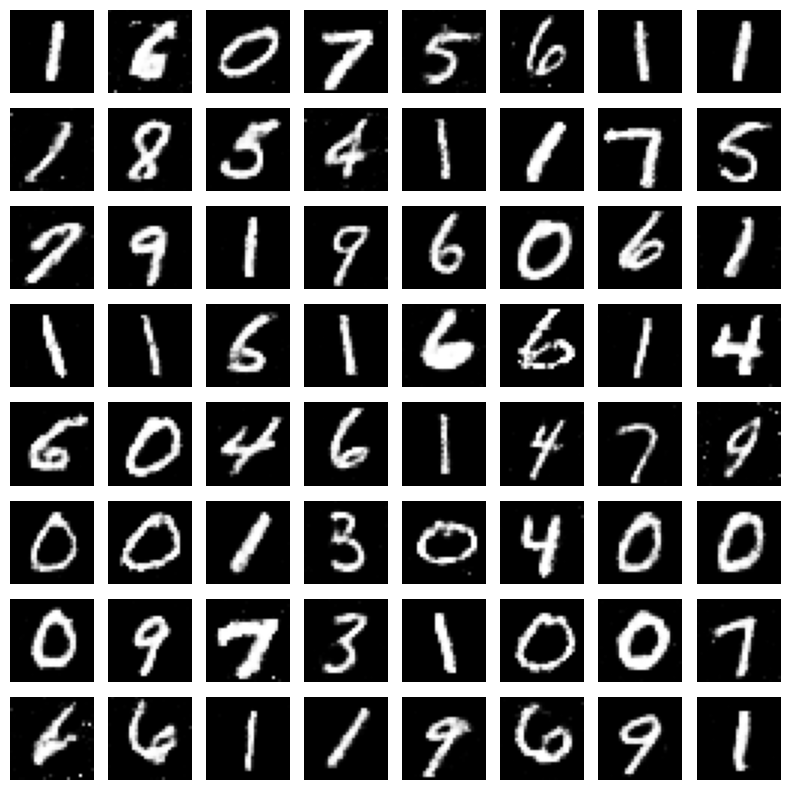

In [ ]:
generator.eval()

z = torch.randn(64, noise_dim, device=device)
generated_images = generator(z).cpu()

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img = generated_images[i].view(28,28).detach().numpy()
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Этап 2б. Реализация и обучение Conditional GAN

In [2]:
class ConditionalGenerator(nn.Module):
    def __init__(self, noise_dim=100, num_classes=10, output_shape=(1, 28, 28)):
        super(ConditionalGenerator, self).__init__()
        self.output_shape = output_shape
        self.img_size = int(torch.prod(torch.tensor(output_shape)))

        self.fc = nn.Sequential(
            nn.Linear(noise_dim + num_classes, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 768),
            nn.BatchNorm1d(768),
            nn.ReLU(),
            nn.Linear(768, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Linear(1024, self.img_size),
            nn.Tanh()
        )

    def forward(self, z, c):
        input = torch.cat([z, c], dim=1)
        img = self.fc(input)
        img = img.view(input.size(0), *self.output_shape)
        return img

In [3]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self, input_shape=(1, 28, 28), num_classes=10):
        super(ConditionalDiscriminator, self).__init__()
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.img_dim = int(torch.prod(torch.tensor(input_shape)))

        self.fc = nn.Sequential(
            nn.Linear(self.img_dim + num_classes, 1024),
            nn.LeakyReLU(0.2, True),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img, c):
        input = torch.cat([img.view(img.size(0), -1), c], dim=1)
        result = self.fc(input)
        return result


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 128
noise_dim = 100
num_classes = 10

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [5]:
train_dataset = dset.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

generator = ConditionalGenerator(noise_dim=noise_dim, num_classes=num_classes, output_shape=(1, 28, 28)).to(device)
discriminator = ConditionalDiscriminator(input_shape=(1, 28, 28), num_classes=num_classes).to(device)

criterion = criterion = nn.BCELoss()

optimizer_g = optim.Adam(generator.parameters(), lr=1e-4, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.5, 0.999))

In [6]:
def save_results_cgan(epoch):

    with torch.no_grad():
        sample_noise = torch.randn(64, noise_dim, device=device)
        sample_labels = torch.arange(0, 64, device=device) % num_classes
        sample_labels_onehot = F.one_hot(sample_labels, num_classes)
        fake_samples = generator(sample_noise, sample_labels_onehot)

        fig, axes = plt.subplots(8, 8, figsize=(8, 8))
        for i, ax in enumerate(axes.flat):
            img = fake_samples[i].cpu().view(28, 28).numpy()
            ax.imshow(img, cmap="gray", interpolation="nearest")
            ax.set_title(f"Label: {sample_labels[i].item()}", fontsize=8)
            ax.axis("off")

        plt.tight_layout()
        plt.savefig(f'./cgan/results_{epoch}.png')

In [ ]:
epochs = 100
num_batches = len(train_loader)

generator.train()

for epoch in tqdm(range(epochs)):
    d_loss_total = 0
    g_loss_total = 0
    for i, (real_images, labels) in enumerate(train_loader):
        real_images = real_images.to(device)
        labels = labels.to(device)
        batch_size = real_images.size(0)

        conditions = F.one_hot(labels, num_classes=10)

        real_labels = torch.ones((batch_size, 1), device=device)
        fake_labels = torch.zeros((batch_size, 1), device=device)

        optimizer_d.zero_grad()
        outputs = discriminator(real_images, conditions)
        d_loss_real = criterion(outputs, real_labels)
        d_loss_real.backward()

        noise = torch.randn((batch_size, 100), device=device)
        fake_images = generator(noise, conditions)
        outputs = discriminator(fake_images.detach(), conditions)
        d_loss_fake = criterion(outputs, fake_labels)
        d_loss_fake.backward()

        optimizer_d.step()

        d_loss = d_loss_real + d_loss_fake
        d_loss_total += d_loss.item()

        optimizer_g.zero_grad()
        outputs = discriminator(fake_images, conditions)
        g_loss = criterion(outputs, real_labels)
        g_loss.backward()

        optimizer_g.step()

        g_loss_total += g_loss.item()

    print(f'Epoch [{epoch+1}/{epochs}], '
          f'D Loss: {d_loss_total/num_batches:.4f}, '
          f'G Loss: {g_loss_total/num_batches:.4f}')
    
    if epoch % 5 == 0:
        save_results_cgan(epoch)

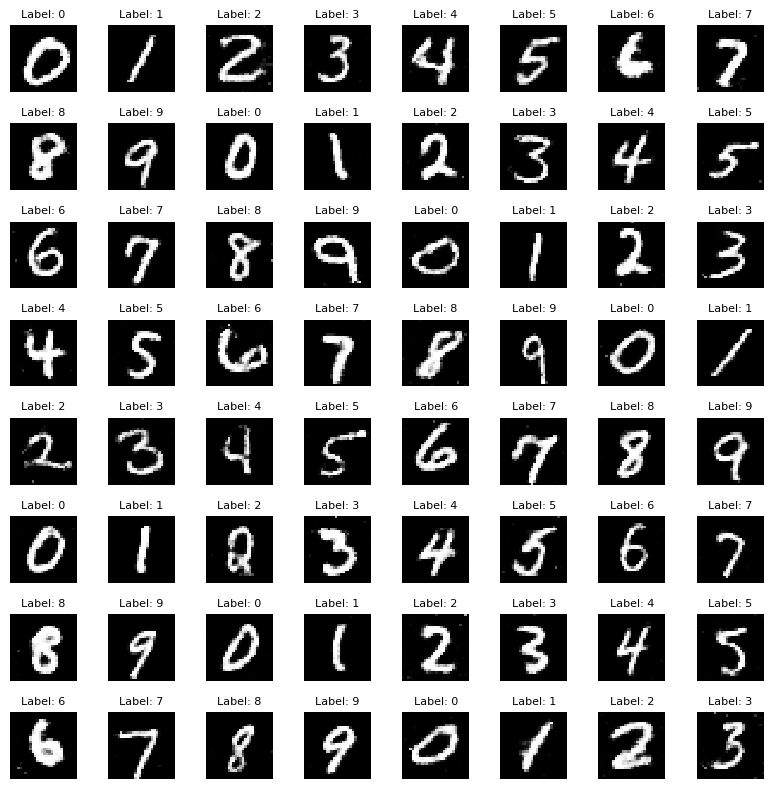

In [15]:
with torch.no_grad():
    sample_noise = torch.randn(64, noise_dim, device=device)
    sample_labels = torch.arange(0, 64, device=device) % num_classes
    sample_labels_onehot = F.one_hot(sample_labels, num_classes)
    fake_samples = generator(sample_noise, sample_labels_onehot)

    fig, axes = plt.subplots(8, 8, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        img = fake_samples[i].cpu().view(28, 28).numpy()
        ax.imshow(img, cmap="gray", interpolation="nearest")
        ax.set_title(f"Label: {sample_labels[i].item()}", fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [16]:
torch.save(generator.state_dict(), 'cgan_generator_weights.pth')
torch.save(discriminator.state_dict(), 'cgan_discriminator_weights.pth')

### Этап 3. Анализ латентного пространства и интерполяция (для CVAE и CGAN)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def interpolate(cvae, gan, class_a=3, class_b=7, num_steps=10):
    cvae.eval()
    gan.eval()
    
    c_a = F.one_hot(torch.tensor([class_a]), 10).float().to(device)
    c_b = F.one_hot(torch.tensor([class_b]), 10).float().to(device)
    
    with torch.no_grad():
        z_a = torch.randn(1, 100, device=device)
        z_b = torch.randn(1, 100, device=device)
        
        vae_images = []
        for alpha in np.linspace(0, 1, num_steps):
            z_interp = alpha * z_a + (1 - alpha) * z_b
            c_interp = alpha * c_a + (1 - alpha) * c_b
            recon = cvae.decoder(z_interp, c_interp)
            vae_images.append(recon.cpu().numpy())
    
    with torch.no_grad():
        z_a = torch.randn(1, 100, device=device)
        z_b = torch.randn(1, 100, device=device)
        
        gan_images = []
        for alpha in np.linspace(0, 1, num_steps):
            # z_interp = alpha * z_a + (1 - alpha) * z_b
            c_interp = alpha * c_a + (1 - alpha) * c_b
            fake = gan(z_interp, c_interp)
            gan_images.append(fake.cpu().numpy())
    
    fig, axes = plt.subplots(2, num_steps, figsize=(20, 4))
    fig.suptitle(f'Интерполяция: Класс {class_a} → Класс {class_b}', fontsize=16)
    
    for i, ax in enumerate(axes[0]):
        img = vae_images[i][0].reshape(28, 28)
        ax.imshow(img, cmap='gray')
        ax.axis('off')
    axes[0][0].set_ylabel('CVAE Decoder')
    
    for i, ax in enumerate(axes[1]):
        img = (gan_images[i][0][0] + 1) / 2 
        ax.imshow(img, cmap='gray')
        ax.axis('off')
    axes[1][0].set_ylabel('cGAN Generator')
    
    plt.tight_layout()
    plt.savefig('interpolation.png', dpi=150)
    plt.show()

In [11]:
class BetterEncoder(nn.Module):
    def __init__(self, input_dim=784, condition_dim=10, hidden_dim=400, latent_dim=20):
        super(BetterEncoder, self).__init__()
        self.fc_h1 = nn.Linear(input_dim + condition_dim, hidden_dim)
        self.fc_h2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)

    def forward(self, x, c):
        input = torch.cat([x, c], dim=1)
        h = F.relu(self.fc_h2(
            F.relu(self.fc_h1(input))
            ))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
class BetterDecoder(nn.Module):
    def __init__(self, latent_dim=20, condition_dim=10, hidden_dim=400, output_dim=784):
        super(BetterDecoder, self).__init__()
        self.fc_h = nn.Linear(latent_dim + condition_dim, hidden_dim // 2)
        self.fc_recon1 = nn.Linear(hidden_dim // 2, hidden_dim)
        self.fc_recon2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, z, c):
        input = torch.cat([z, c], dim=1)
        h = F.relu(self.fc_h(input))
        x_recon = F.sigmoid(self.fc_recon2(F.relu(self.fc_recon1(h))))
        return x_recon
    
class BetterVAE(nn.Module):
    def __init__(self, input_dim=784, condition_dim=10, hidden_dim=400, latent_dim=50):
        super(BetterVAE, self).__init__()
        self.encoder = BetterEncoder(input_dim, condition_dim, hidden_dim, latent_dim)
        self.decoder = BetterDecoder(latent_dim, condition_dim, hidden_dim, input_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + std * epsilon
        return z

    def forward(self, x, c):
        mu, logvar = self.encoder(x, c)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z, c)
        return x_recon, mu, logvar

In [12]:
class ConditionalGenerator(nn.Module):
    def __init__(self, noise_dim=100, num_classes=10, output_shape=(1, 28, 28)):
        super(ConditionalGenerator, self).__init__()
        self.output_shape = output_shape
        self.img_size = int(torch.prod(torch.tensor(output_shape)))

        self.fc = nn.Sequential(
            nn.Linear(noise_dim + num_classes, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 768),
            nn.BatchNorm1d(768),
            nn.ReLU(),
            nn.Linear(768, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Linear(1024, self.img_size),
            nn.Tanh()
        )

    def forward(self, z, c):
        input = torch.cat([z, c], dim=1)
        img = self.fc(input)
        img = img.view(input.size(0), *self.output_shape)
        return img

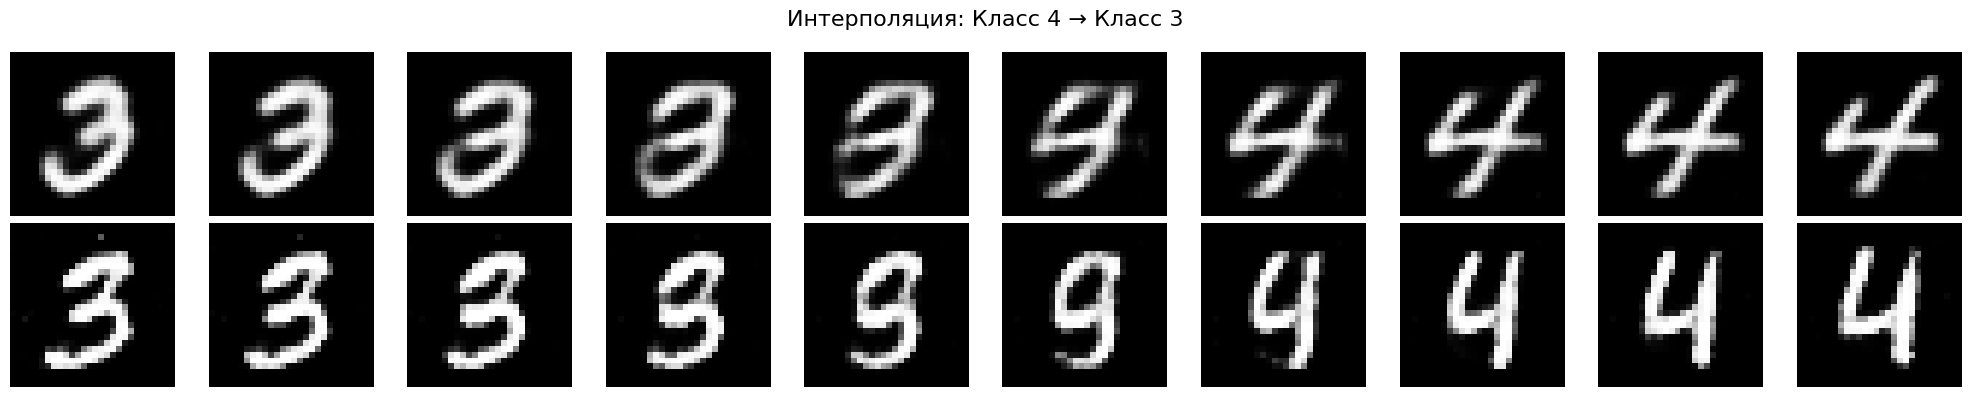

In [19]:
vae = BetterVAE(input_dim=784, condition_dim=10, hidden_dim=400, latent_dim=100).to(device)
gan = ConditionalGenerator(noise_dim=100, num_classes=10, output_shape=(1, 28, 28)).to(device)

vae.load_state_dict(torch.load('cvae_weights.pth', map_location=device))
gan.load_state_dict(torch.load('cgan_generator_weights.pth', map_location=device))

interpolate(vae, gan, class_a=4, class_b=3, num_steps=10)